# Eksperimen MSML - UCI Bank Marketing

**Tujuan:** memprediksi apakah nasabah akan berlangganan deposito berjangka. Dataset UCI memiliki 45.211 observasi, 16 fitur, serta target biner `y`. Sumber: https://archive.ics.uci.edu/dataset/222/bank+marketing

**Catatan kebocoran data:** `duration` adalah lama panggilan yang baru diketahui setelah panggilan selesai. Fitur ini disisihkan untuk model yang digunakan sebelum kampanye agar evaluasi lebih realistis.

# 2. Import Library

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
BASE = Path.cwd()
if not (BASE / 'namadataset_raw').exists():
    BASE = BASE / 'Eksperimen_SML_Iswahyudi'
RAW = BASE / 'namadataset_raw' / 'bank_marketing_raw.csv'
OUT = BASE / 'namadataset_preprocessing'
sns.set_theme(style='whitegrid')

# 3. Memuat Dataset

In [3]:
!pip install ucimlrepo

In [4]:
if not RAW.exists():
    from ucimlrepo import fetch_ucirepo
    data = fetch_ucirepo(id=222)
    RAW.parent.mkdir(parents=True, exist_ok=True)
    pd.concat([data.data.features, data.data.targets], axis=1).to_csv(RAW, index=False)
df_raw = pd.read_csv(RAW)
print('Shape:', df_raw.shape)
display(df_raw.head())
display(df_raw.info())

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

# 4. Exploratory Data Analysis (EDA)

Missing values (top):


,0
poutcome,36959
contact,13020
education,1857
job,288
age,0
default,0
balance,0
housing,0
marital,0
loan,0


Duplicates: 0
Target distribution:


,proportion
y,
no,0.883015
yes,0.116985


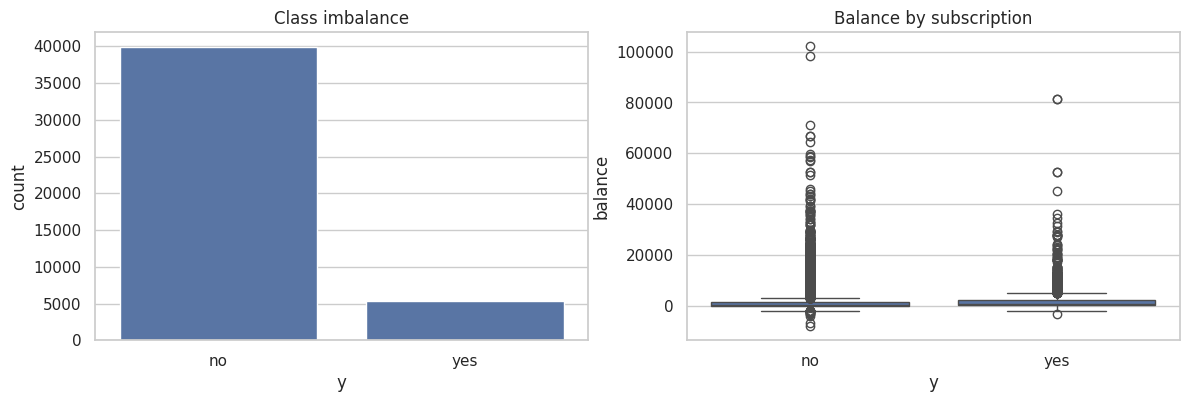

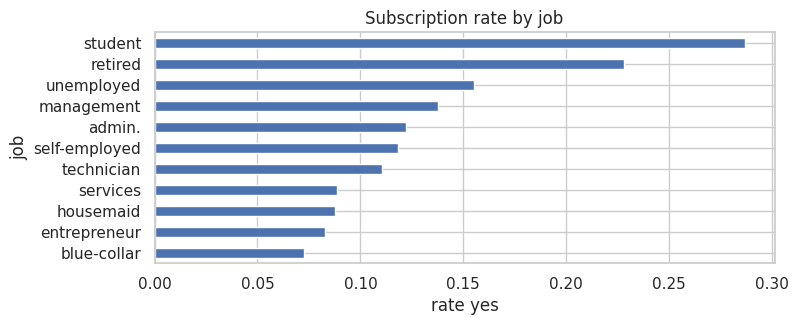

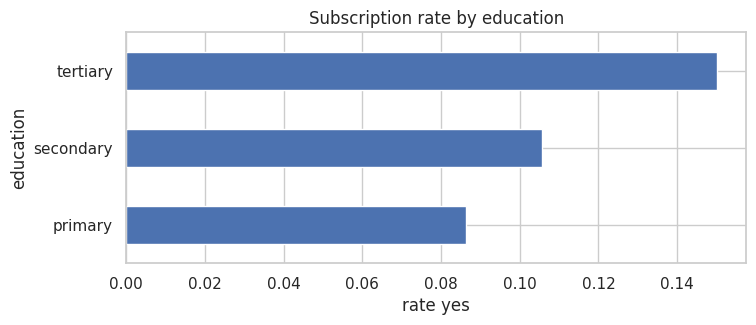

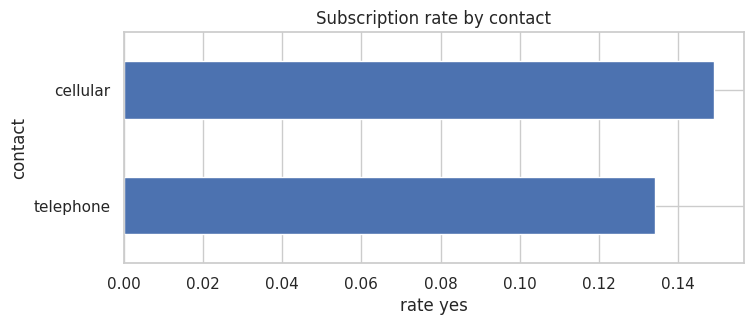

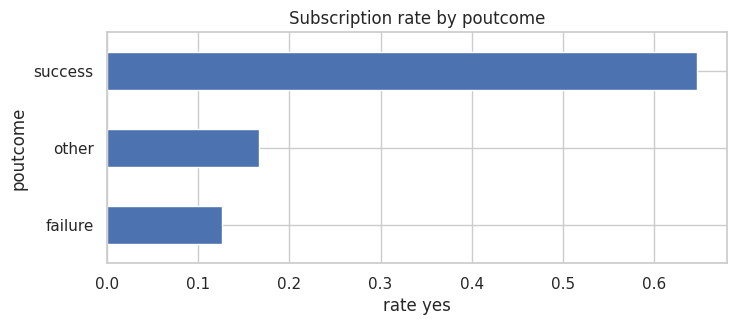

In [5]:
print('Missing values (top):')
display(df_raw.isna().sum().sort_values(ascending=False).head(10))
print('Duplicates:', df_raw.duplicated().sum())
print('Target distribution:')
display(df_raw['y'].value_counts(normalize=True).rename('proportion'))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=df_raw, x='y', ax=axes[0]); axes[0].set_title('Class imbalance')
sns.boxplot(data=df_raw, x='y', y='balance', ax=axes[1]); axes[1].set_title('Balance by subscription')
plt.show()
for col in ['job', 'education', 'contact', 'poutcome']:
    rate = pd.crosstab(df_raw[col], df_raw['y'], normalize='index').get('yes', pd.Series(dtype=float)).sort_values()
    rate.plot.barh(figsize=(8,3), title=f'Subscription rate by {col}'); plt.xlabel('rate yes'); plt.show()

# 5. Data Preprocessing

In [6]:
# Manual experimental preprocessing. The same logic is converted into automate_Iswahyudi.py.
df = df_raw.drop_duplicates().copy().replace('unknown', np.nan)
df['pdays_never_contacted'] = (df['pdays'] == -1).astype(int)
# Exclude post-call duration to avoid target leakage for a pre-campaign use case.
df = df.drop(columns=['duration'])
y = (df.pop('y').str.lower() == 'yes').astype(int)
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]
preprocessor = ColumnTransformer([
 ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
 ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
], verbose_feature_names_out=False)
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)
features = preprocessor.get_feature_names_out()
OUT.mkdir(parents=True, exist_ok=True)
pd.DataFrame(X_train_ready, columns=features).assign(y=y_train.to_numpy()).to_csv(OUT/'train.csv', index=False)
pd.DataFrame(X_test_ready, columns=features).assign(y=y_test.to_numpy()).to_csv(OUT/'test.csv', index=False)
print({'train_shape': X_train_ready.shape, 'test_shape': X_test_ready.shape, 'positive_rate_train': y_train.mean(), 'positive_rate_test': y_test.mean()})
display(pd.read_csv(OUT/'train.csv').head())

{'train_shape': (36168, 47), 'test_shape': (9043, 47), 'positive_rate_train': np.float64(0.11698186241981863), 'positive_rate_test': np.float64(0.11699657193409267)}


,age,balance,day_of_week,campaign,pdays,previous,pdays_never_contacted,job_admin.,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,y
0,-0.460434,-0.164410,1.582124,-0.246104,-0.410910,-0.241509,0.471755,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1,-1.589641,0.899627,-1.298384,0.398202,1.446096,2.664584,-2.119745,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
2,0.292371,-0.365486,-0.458236,0.398202,-0.410910,-0.241509,0.471755,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,0.668773,-0.445003,1.822166,2.653271,-0.410910,-0.241509,0.471755,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,-0.272233,-0.361249,1.222060,2.331118,-0.410910,-0.241509,0.471755,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


## Kesimpulan eksperimen
- Dataset berisi kategorikal dan numerik; nilai `unknown` diperlakukan sebagai missing value.
- Data diduplikasi dihapus, pembagian train/test dibuat stratified, dan transformer hanya di-fit pada train untuk mencegah leakage.
- Kelas positif tidak seimbang, jadi model berikutnya memakai `class_weight='balanced'` serta metrik ROC-AUC dan average precision.
- Pipeline produksi yang ekuivalen tersedia di `preprocessing/automate_Iswahyudi.py`.